In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
#Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# Cargar el dataset
df = pd.read_excel("dataset_set_A_aguas_residuales.xlsx")

In [ ]:
#Mostrar primeras filas
print(df.head())

In [54]:
#Información general
print("\nInformación del dataset:")
print(df.info())
print("\nColumnas del dataset:")
print(df.columns)
print("\nValores nulos:")
print(df.isnull().sum())


Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Fecha         200 non-null    datetime64[us]
 1   Planta        200 non-null    str           
 2   Caudal        200 non-null    int64         
 3   DBO_Entrada   200 non-null    int64         
 4   SST_Entrada   200 non-null    int64         
 5   pH            200 non-null    float64       
 6   Energia       200 non-null    float64       
 7   Lodos         200 non-null    float64       
 8   DBO_Salida    200 non-null    float64       
 9   Cumplimiento  200 non-null    int64         
 10  Eficiencia    200 non-null    float64       
 11  Estado        45 non-null     str           
dtypes: datetime64[us](1), float64(5), int64(4), str(2)
memory usage: 21.5 KB
None

Columnas del dataset:
Index(['Fecha', 'Planta', 'Caudal', 'DBO_Entrada', 'SST_Entrada', 'pH',
  

In [34]:
# Renombrar columnas
df = df.rename(columns={
    "fecha_registro": "Fecha",
    "planta": "Planta",
    "caudal_entrada_m3_d": "Caudal",
    "DBO_entrada_mg_L": "DBO_Entrada",
    "SST_entrada_mg_L": "SST_Entrada",
    "pH_entrada": "pH",
    "energia_aeracion_kWh": "Energia",
    "lodos_generados_kg_d": "Lodos",
    "DBO_salida_mg_L": "DBO_Salida",
    "cumplimiento_norma": "Cumplimiento"
})

In [55]:
#Limpieza de datos
#convertir fecha
df["Fecha"] = pd.to_datetime(df["Fecha"])
#verificar duplicados
print("\nDuplicados:")
print(df.duplicated().sum())


Duplicados:
0


In [56]:
#creación de variables
#calcular eficiencia
df["Eficiencia"] =(
(df["DBO_Entrada"] - df["DBO_Salida"])
    / df["DBO_Entrada"]
) * 100
#Estado normativo
df["Estado"] = df["Cumplimiento"].map({
    1: "Cumple",
    2: "No Cumple"
})

In [57]:
# Estadisticas generales
print("\nEstadísticas descriptivas:")
print(df.describe())
#Indicadores principales
print("\nIndicadores principales:")

print("DBO salida promedio:")
print(round(df["DBO_Salida"].mean(), 2))

print("\nEficiencia promedio:")
print(round(df["Eficiencia"].mean(), 2))

print("\nCaudal promedio:")
print(round(df["Caudal"].mean(), 2))

print("\nConsumo energético promedio:")
print(round(df["Energia"].mean(), 2))


Estadísticas descriptivas:
                     Fecha       Caudal  DBO_Entrada  SST_Entrada         pH  \
count                  200   200.000000   200.000000   200.000000  200.00000   
mean   2025-08-29 15:50:24  5059.285000   280.145000   232.670000    7.16240   
min    2025-07-01 00:00:00  1500.000000    90.000000    70.000000    6.18000   
25%    2025-07-31 00:00:00  4193.750000   223.000000   192.500000    6.84750   
50%    2025-08-30 12:00:00  5092.500000   284.000000   233.500000    7.14000   
75%    2025-09-29 06:00:00  6037.750000   333.250000   277.500000    7.45250   
max    2025-10-28 00:00:00  9205.000000   481.000000   391.000000    8.27000   
std                    NaN  1410.971334    75.566497    64.289398    0.42381   

           Energia       Lodos  DBO_Salida  Cumplimiento  Eficiencia  
count   200.000000  200.000000  200.000000     200.00000  200.000000  
mean   1256.394500  428.795500   36.177500       0.22500   87.092908  
min     279.700000  113.700000   10.20

In [58]:
# Analisis por planta
analisis_plantas = df.groupby("Planta")[
    ["Caudal","DBO_Entrada","DBO_Salida","Energia","Lodos","Eficiencia"]
].mean()

print("\nPromedio por planta:")
print(analisis_plantas)


Promedio por planta:
                    Caudal  DBO_Entrada  DBO_Salida      Energia       Lodos  \
Planta                                                                         
Planta Centro  5112.720000   285.186667   35.901333  1260.854667  433.010667   
Planta Norte   5287.873239   275.845070   36.560563  1299.308451  450.471831   
Planta Sur     4684.518519   278.796296   36.057407  1193.775926  394.440741   

               Eficiencia  
Planta                     
Planta Centro   87.513110  
Planta Norte    86.646784  
Planta Sur      87.095864  


In [ ]:
#Graficos exploratorios
#DBO salida por fecha
plt.figure()
plt.plot(df["Fecha"], df["DBO_Salida"])
plt.title("Tendencia temporal DBO salida")
plt.xlabel("Fecha")
plt.ylabel("DBO_salida")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Gráfico eficiencia promedio por planta
plt.figure()
df.groupby("Planta")["Eficiencia"].mean().plot(
    kind="bar"
)
plt.title("Eficiencia promedio por planta")
plt.xlabel("Planta")
plt.ylabel("Eficiencia (%)")
plt.show()

In [ ]:
#Gráfico caudal vs. DBO salida
plt.figure()
plt.scatter(
    df["Caudal"],
    df["DBO_Salida"]
)
plt.title("Caudal vs DBO salida")
plt.xlabel("Caudal")
plt.ylabel("DBO salida")
plt.show()

In [ ]:
#Gráfico de consumo energético
plt.figure()
sns.boxplot(
    x=df["Planta"],
    y=df["Energia"]
)
plt.title("Consumo energético por planta")
plt.show()

In [ ]:
#Gráfico distribución eficiencia
plt.figure()
plt.hist(
    df["Eficiencia"],
    bins=20
)
plt.title("Distribución de eficiencia")
plt.xlabel("Eficiencia")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# Gráfico normativo
plt.figure()
df["Estado"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Cumplimiento normativo")
plt.ylabel("")
plt.show()

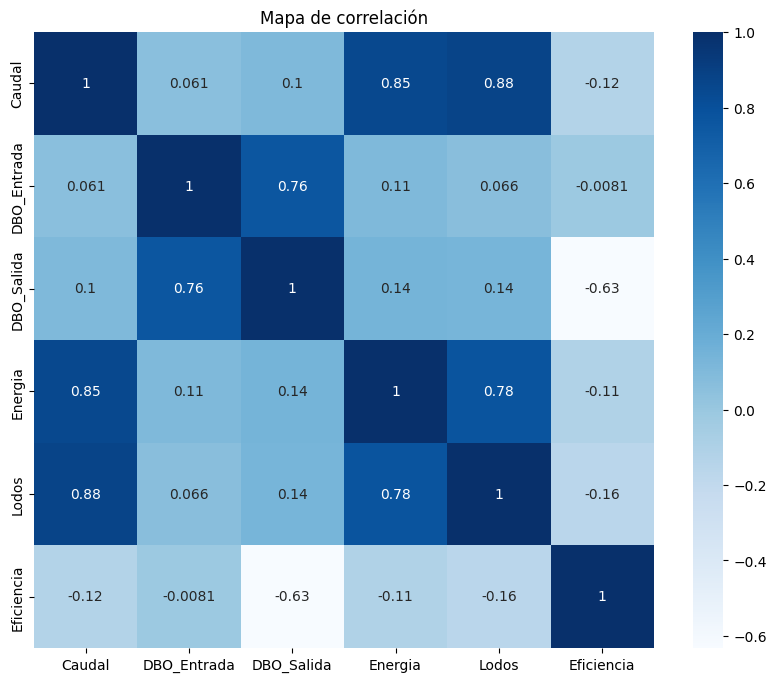

In [52]:
#Gráfico correlación
plt.figure(figsize=(10,8))
sns.heatmap(
    df[
        [
            "Caudal",
            "DBO_Entrada",
            "DBO_Salida",
            "Energia",
            "Lodos",
            "Eficiencia"
        ]
    ].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Mapa de correlación")
plt.show()

In [46]:
#Exportar reportes
#Reporte operaciones
operaciones = df[
    [
        "Fecha",
        "Planta",
        "Caudal",
        "DBO_Entrada",
        "DBO_Salida",
        "Energia",
        "Lodos",
        "Eficiencia"
    ]
]
operaciones.to_excel(
    "reporte_operaciones.xlsx",
    index=False
)

In [47]:
#Exportar reportes gestión ambiental
ambiental = df[
    [
        "Fecha",
        "Planta",
        "DBO_Salida",
        "Estado"
    ]
]
ambiental.to_excel(
    "reporte_gestion_ambiental.xlsx",
    index=False
)

In [ ]:
#Conclusiones automáticas
print("\n==============================")
print("CONCLUSIONES DEL ANÁLISIS")
print("==============================")

print(f"""
El análisis exploratorio permitió identificar
el comportamiento operacional de las plantas
de tratamiento de AquaLimpia S.A.

La eficiencia promedio del sistema fue de
{round(df["Eficiencia"].mean(),2)}%.

La DBO promedio de salida fue de
{round(df["DBO_Salida"].mean(),2)} mg/L.

El porcentaje de cumplimiento normativo fue de
{round((df["Cumplimiento"].mean()*100),2)}%.

Se observaron variaciones entre plantas
relacionadas con el caudal de entrada,
el consumo energético y la generación de lodos.

Los resultados permiten apoyar la toma de
decisiones operacionales y ambientales,
facilitando la detección de desviaciones
y la evaluación del desempeño de las plantas.
""")

print("\nArchivos exportados correctamente.")
print("- reporte_operaciones.xlsx")
print("- reporte_gestion_ambiental.xlsx")